# Visualization of OKLCH colour space

Creating a visualization of the OKLCH color space requires converting OKLCH coordinates (L,C,h) into a displayable format like sRGB. OKLCH is a cylindrical representation of the Oklab color space, which is designed to be perceptually uniform.

OKLCH to sRGB Transformation Pipeline
1. OKLCH to Oklab

The cylindrical coordinates (Chroma and Hue) are converted to Cartesian coordinates (a and b):

    a=C⋅cos(h)

    b=C⋅sin(h)

2. Oklab to LMS'

This step transforms the Oklab coordinates into a non-linear LMS cone space using the following matrix multiplication:

$$\begin{bmatrix} L' \\ M' \\ S' \end{bmatrix} = \begin{bmatrix} 1 & 0.3963377774 & 0.2158037573 \\ 1 & -0.1055613458 & -0.0638541728 \\ 1 & -0.0894841775 & -1.2914855480 \end{bmatrix} \begin{bmatrix} L \\ a \\ b \end{bmatrix}$$

3. LMS' to LMS

The non-linearity is removed by cubing the components:

    l=(L′)3

    m=(M′)3

    s=(S′)3

4. LMS to Linear sRGB

The values are converted from LMS space to linear sRGB using the transformation matrix defined by Björn Ottosson:
$$\begin{bmatrix} R_{linear} \\ G_{linear} \\ B_{linear} \end{bmatrix} = \begin{bmatrix} 4.0767416621 & -3.3077115913 & 0.2309699292 \\ -1.2684380046 & 2.6097574011 & -0.3413193965 \\ -0.0041960863 & -0.7034186147 & 1.7076147010 \end{bmatrix} \begin{bmatrix} l \\ m \\ s \end{bmatrix}$$

5. Linear sRGB to sRGB

Finally, apply the standard sRGB gamma correction to account for display non-linearity. For each channel Clinear​∈{R,G,B}:
$$C_{srgb} = \begin{cases} 12.92 \times C_{linear} & \text{if } C_{linear} \le 0.0031308 \\ 1.055 \times (C_{linear})^{1/2.4} - 0.055 & \text{if } C_{linear} > 0.0031308 \end{cases}$$

Plot represents the 3D sRGB Gamut: A point cloud representing the volume of sRGB colors in the a,b,L coordinate system.

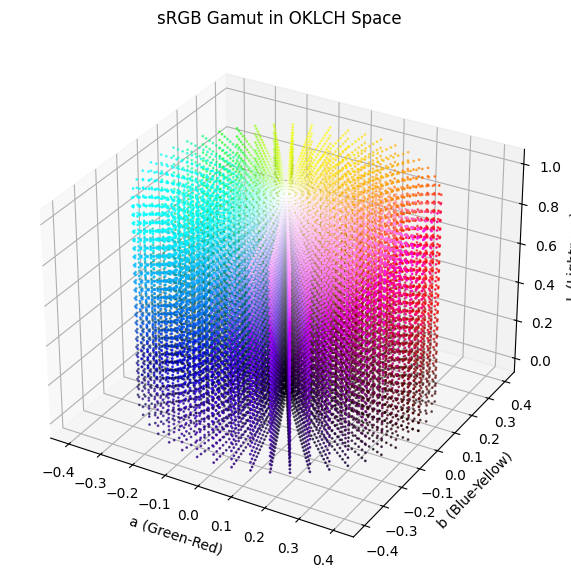

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def oklch_to_srgb(L, C, h_deg):
    # 1. OKLCH to Oklab
    h = np.radians(h_deg)
    a = C * np.cos(h)
    b = C * np.sin(h)
    
    # 2. Oklab to LMS'
    l_p = L + 0.3963377774 * a + 0.2158037573 * b
    m_p = L - 0.1055613458 * a - 0.0638541728 * b
    s_p = L - 0.0894841775 * a - 1.2914855480 * b

    # 3. LMS' to LMS
    l, m, s = l_p**3, m_p**3, s_p**3

    # 4. LMS to Linear sRGB
    r_lin = +4.0767416621 * l - 3.3077115913 * m + 0.2309699292 * s
    g_lin = -1.2684380046 * l + 2.6097574011 * m - 0.3413193965 * s
    b_lin = -0.0041960863 * l - 0.7034186147 * m + 1.7076147010 * s
    
    # 5. Linear to sRGB (Gamma correction)
    def gamma(c):
        return np.where(c <= 0.0031308, 12.92 * c, 1.055 * (np.maximum(c, 0)**(1/2.4)) - 0.055)
    
    return np.clip(gamma(r_lin), 0, 1), np.clip(gamma(g_lin), 0, 1), np.clip(gamma(b_lin), 0, 1)

# Sampling the space
L_grid, C_grid, h_grid = np.meshgrid(np.linspace(0, 1, 25), 
                                     np.linspace(0, 0.4, 25), 
                                     np.linspace(0, 360, 50), indexing='ij')

r, g, b = oklch_to_srgb(L_grid, C_grid, h_grid)
colors = np.stack([r, g, b], axis=-1)

# Plotting
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
h_rad = np.radians(h_grid)
ax.scatter(C_grid * np.cos(h_rad), C_grid * np.sin(h_rad), L_grid, c=colors.reshape(-1, 3), s=1)
ax.set_xlabel('a (Green-Red)')
ax.set_ylabel('b (Blue-Yellow)')
ax.set_zlabel('L (Lightness)')
plt.title("sRGB Gamut in OKLCH Space")
plt.show()